In [106]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout

In [107]:
df = pd.read_csv('/kaggle/input/datasets/prashantrajput9405/tweets-dataset/Tweets.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [108]:
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [109]:
# ==========================================
# 🧹 TEXT PREPROCESSING & CLEANING
# ==========================================
df['text'] = df['text'].fillna("")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean'] = df['text'].apply(clean_text)

In [110]:

# ==========================================
# 🏷️ LABEL ENCODING (MULTICLASS)
# ==========================================df = df[df['sentiment'] != 'neutral']

df['label'] = df['sentiment'].map({
    'negative': 0,
    'neutral': 1,
    'positive': 2
})

print(df['label'].value_counts())

label
2    8582
0    7781
Name: count, dtype: int64


In [111]:

# ==========================================
# 🔤 TOKENIZATION FOR RNN/LSTM/GRU
# ==========================================
max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean'])

X = tokenizer.texts_to_sequences(df['clean'])
X = pad_sequences(X, maxlen=max_len)

y = df['label'].values

lengths = df['clean'].apply(lambda x: len(x.split())).values

In [112]:
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    X, y, lengths, test_size=0.2, random_state=42
)

In [113]:
# ==========================================
# 🧠 MODEL DEFINITIONS (RNN, LSTM, GRU)
# ==========================================
def get_rnn():
    model = Sequential()
    model.add(Embedding(max_words, 128))
    model.add(SimpleRNN(64))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


def get_lstm():
    model = Sequential()
    model.add(Embedding(max_words, 128))
    model.add(LSTM(64))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


def get_gru():
    model = Sequential()
    model.add(Embedding(max_words, 128))
    model.add(GRU(64))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [114]:
# ==========================================
# 🚀 TRAINING MODELS
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

models = {
    'rnn': get_rnn(),
    'lstm': get_lstm(),
    'gru': get_gru()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...\n")

    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")


Training rnn...

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5587 - loss: 0.7377 - val_accuracy: 0.7769 - val_loss: 0.4668
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8539 - loss: 0.3576 - val_accuracy: 0.8762 - val_loss: 0.3229
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9344 - loss: 0.1836 - val_accuracy: 0.8518 - val_loss: 0.3795
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9713 - loss: 0.0989 - val_accuracy: 0.8633 - val_loss: 0.4040
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
rnn Accuracy: 0.8592

Training lstm...

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.5850 - loss: 0.7380 - val_accuracy: 0.8778 - val_loss: 0.3258
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8949 - loss: 0.2694 - val_accuracy: 0.8785 - val_loss: 0.3064
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9417 - loss: 0.1673 - val_accuracy: 0.8816 - val_loss: 0.

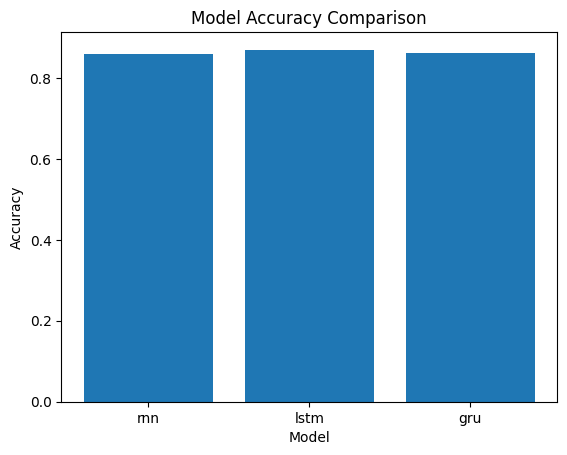

In [115]:
# PLOT ACCURACY
plt.figure()
plt.bar(results.keys(), results.values())
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.show()

In [116]:


def accuracy_by_length(model):
    bins = [0, 5, 10, 20, 50]
    accs = []

    for i in range(len(bins) - 1):
        idx = (len_test >= bins[i]) & (len_test < bins[i+1])
        indices = np.where(idx)[0]

        if len(indices) == 0:
            accs.append(0)
            continue

        X_subset = X_test[indices]
        y_subset = y_test[indices]

        preds = model.predict(X_subset)

        
        preds = np.argmax(preds, axis=1)

        acc = accuracy_score(y_subset, preds)
        accs.append(acc)

    return accs

In [117]:
print("\nFinal Results:")
print(results)


Final Results:
{'rnn': 0.8591506263366941, 'lstm': 0.8698441796516957, 'gru': 0.8609838069049801}


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


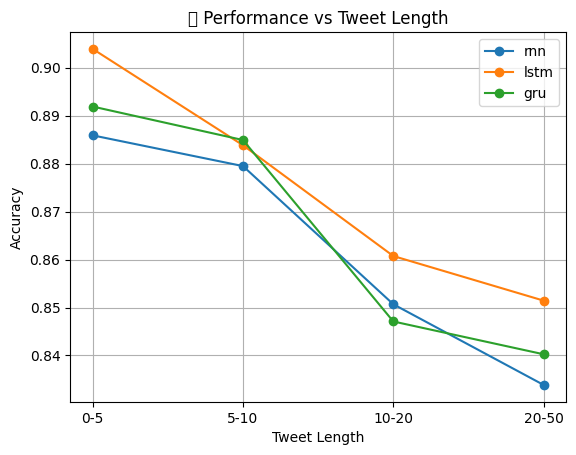

In [118]:
# ==========================================
# 📉 PERFORMANCE vs TWEET LENGTH ANALYSIS
# ==========================================

bins_labels = ['0-5', '5-10', '10-20', '20-50']

plt.figure()

for name, model in models.items():
    accs = accuracy_by_length(model)
    plt.plot(bins_labels, accs, marker='o', label=name)

plt.title('📉 Performance vs Tweet Length')
plt.xlabel('Tweet Length')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

In [119]:
# Prediction function
def predict_sentiment(text, model, tokenizer, max_len=50):
    import re
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    import numpy as np

    # Clean text (same as training)
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)

    # Tokenize
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    # Predict
    pred = model.predict(padded)

    # Multiclass
    label = np.argmax(pred)

    mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    return mapping[label]

**🚀Testing model with real Time tweets**

In [120]:
print("🚀 Testing model with real-time tweets...")
tweet = input("Enter tweet: ")
result = predict_sentiment(tweet, models['gru'], tokenizer)

print("Sentiment:", result)

🚀 Testing model with real-time tweets...


Enter tweet:  India is a great country.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Sentiment: Positive
